**Importing the dependencies**

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

**Setting the seed**

In [42]:
tf.random.set_seed(3)

In [43]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [44]:
print(x_train.shape,x_test.shape, y_train.shape, y_test.shape)

(60000, 28, 28) (10000, 28, 28) (60000,) (10000,)


In [45]:
print(x_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

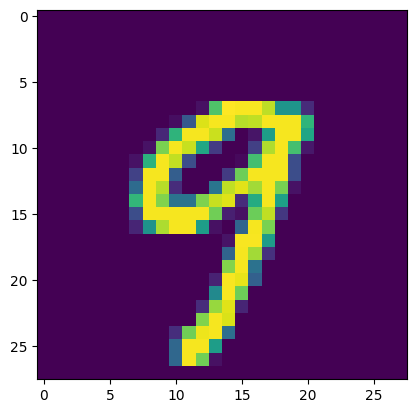

9


In [46]:
#displaying the image

plt.imshow(x_train[45])
plt.show()


#print the corresponding label
print(y_train[45])

In [47]:
print (y_train.shape, y_test.shape)

(60000,) (10000,)


In [48]:
#Unique Values in Y_train
print(np.unique(y_train))

#Unique Values in Y_test
print(np.unique(y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


In [49]:
#Scaling the Values

x_train = x_train/255
x_test = x_test/255

In [50]:
print(x_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

**Building the NEURAL NETWORK (Not CNN)**

**keras.layers.Flatten(input_shape=(28,28)):** This layer transforms the 2D image data (28x28 pixels) into a single 1D array, making it suitable for feeding into a traditional neural network layer.


**keras.layers.Dense(100, activation='relu')**: This is a hidden layer with 100 neurons. It learns complex patterns from the flattened input using the ReLU (Rectified Linear Unit) activation function, which introduces non-linearity.


**keras.layers.Dense(10, activation='sigmoid'): **This is the output layer with 10 neurons, one for each digit (0-9). The sigmoid activation function outputs values between 0 and 1, representing the network's confidence for each digit. For multi-class classification like MNIST, softmax is often preferred for probability distribution.

In [51]:
#Setting up the layers of the neural networks
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [52]:
#compiling the neural network

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [53]:
#training the neural network
model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8437 - loss: 0.5346 - val_accuracy: 0.9461 - val_loss: 0.1746
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9552 - loss: 0.1538 - val_accuracy: 0.9604 - val_loss: 0.1257
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9668 - loss: 0.1089 - val_accuracy: 0.9665 - val_loss: 0.1085
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9745 - loss: 0.0839 - val_accuracy: 0.9695 - val_loss: 0.1027
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9795 - loss: 0.0679 - val_accuracy: 0.9704 - val_loss: 0.1021
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9833 - loss: 0.0556 - val_accuracy: 0.9713 - val_loss: 0.1040
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9860 - loss: 0.0468 - val_accuracy: 0.9716 - val_loss: 0.1050
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9881 - loss: 0.0403 - 

Training Data Accuracy = 99.05%

In [54]:
#Accuracy on train data
loss, accuracy = model.evaluate(x_test, y_test)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9667 - loss: 0.1412
0.9704999923706055


Test Data accuracy = 96.92%

In [55]:
print(x_test.shape)

(10000, 28, 28)


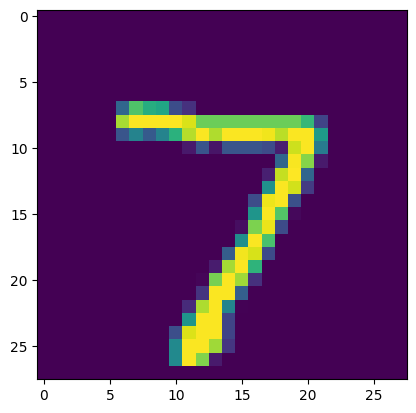

7


In [56]:
plt.imshow(x_test[0])
plt.show()
print(y_test[0])

In [57]:
y_pred= model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [58]:
print(y_pred.shape)

(10000, 10)


In [59]:
print(y_pred[0])

[2.8445836e-02 1.1700296e-05 2.3504277e-01 9.9460512e-01 1.0562941e-05
 9.5643697e-04 3.9201342e-10 9.9999267e-01 7.1824491e-01 9.9245012e-01]


In [60]:
#converting the prediction proabilities to class label
label_image_first = np.argmax(y_pred[0])
print(label_image_first)

7


In [61]:
#converting the prediction probabilities to class label for all tes data points
y_pred_labels = [np.argmax(i) for i in y_pred]
print(y_pred_labels)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(6), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

In [62]:
conf_mat = confusion_matrix(y_test, y_pred_labels)
print(conf_mat)

tf.Tensor(
[[ 953    0    1    1    3    1    6    3    0   12]
 [   0 1113    4    3    5    1    3    1    5    0]
 [   3    0  992   10    6    0    1    9   10    1]
 [   0    0    3  983    3    4    0    5    5    7]
 [   0    0    2    0  964    1    6    3    1    5]
 [   2    0    2   12    3  858    5    3    3    4]
 [   3    2    1    1    8    3  940    0    0    0]
 [   1    0   12    3    5    0    0  997    3    7]
 [   3    0    3    6   10    6    2    2  938    4]
 [   0    2    0    2   23    4    0    6    5  967]], shape=(10, 10), dtype=int32)


Text(158.22222222222223, 0.5, 'Actual')

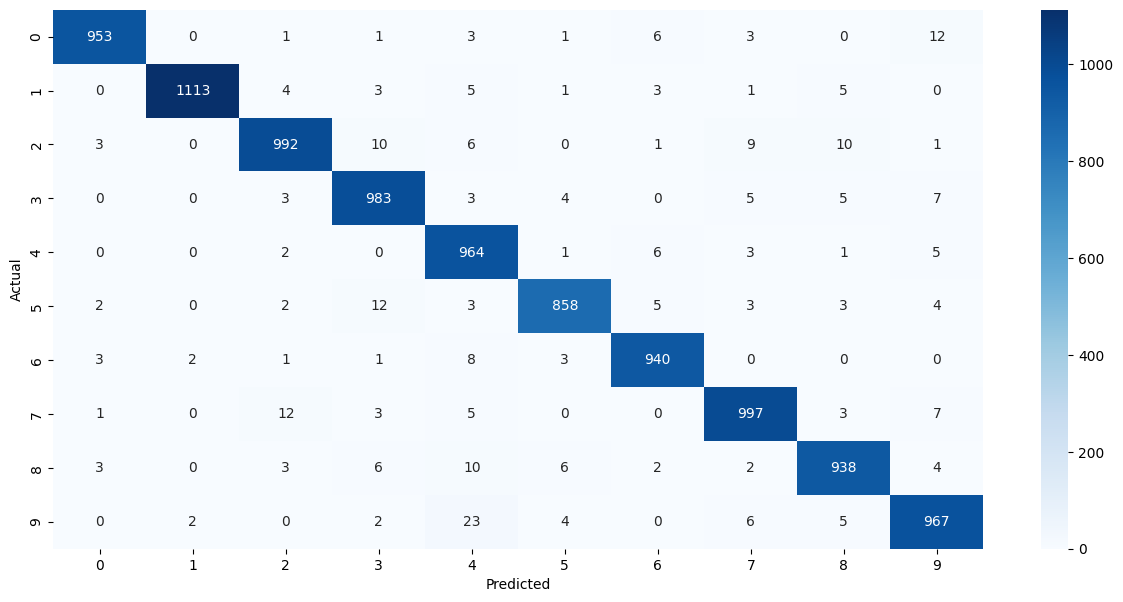

In [63]:
plt.figure(figsize=(15, 7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')


In [73]:
input_image_path = '/content/Testing.png'

input_image = cv2.imread(input_image_path)

In [74]:
type(input_image)

numpy.ndarray

In [75]:
print(input_image)

[[[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]]


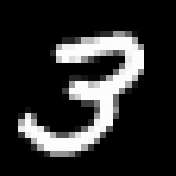

In [76]:
cv2_imshow(input_image)

In [77]:
input_image.shape

(176, 176, 3)

In [78]:
grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

In [79]:
grayscale.shape

(176, 176)

In [80]:
input_image_resize = cv2.resize(grayscale, (28,28))

In [81]:
input_image_resize.shape

(28, 28)

In [82]:
cv2_imshow(input_image_resize)

In [83]:
type(input_image_resize)

numpy.ndarray

In [84]:
image_reshaped = np.reshape(input_image_resize, [1,28,28])

In [85]:
input_prediction = model.predict(image_reshaped)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
[[0. 0. 0. 1. 0. 0. 0. 0. 0. 1.]]


In [86]:
input_pred_label = np.argmax(input_prediction)

In [87]:
print(input_pred_label)

3


**Predictive System of Digit Classification**

Path of the image to be predicted: /content/Test.png


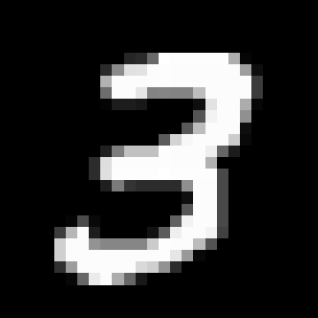

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
The Handwritten Digit is recognised as  3


In [92]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

input_image_resize = cv2.resize(grayscale, (28, 28))

input_image_resize = input_image_resize/255

image_reshaped = np.reshape(input_image_resize, [1,28,28])

input_prediction = model.predict(image_reshaped)

input_pred_label = np.argmax(input_prediction)

print('The Handwritten Digit is recognised as ', input_pred_label)

Path of the image to be predicted: /content/sample_image-300x298.webp


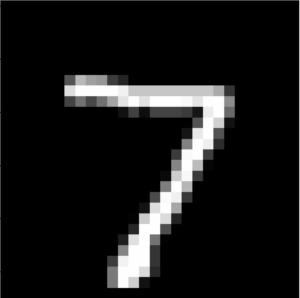

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
The Handwritten Digit is recognised as  7


In [93]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

input_image_resize = cv2.resize(grayscale, (28, 28))

input_image_resize = input_image_resize/255

image_reshaped = np.reshape(input_image_resize, [1,28,28])

input_prediction = model.predict(image_reshaped)

input_pred_label = np.argmax(input_prediction)

print('The Handwritten Digit is recognised as ', input_pred_label)